Visualisation interactive des données...

Défi quotidien : Visualisation interactive des données avec Matplotlib et Seaborn

In [1]:
#Chargement et nettoyage

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import ipywidgets as widgets
from ipywidgets import interact, Dropdown
from IPython.display import display
import warnings
warnings.filterwarnings('ignore')

df = pd.read_excel('US Superstore data.xls')

df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date']  = pd.to_datetime(df['Ship Date'])
df = df.drop_duplicates()

# On cree les colonnes d'annee et de mois pour les analyses temporelles
df['Order Year']  = df['Order Date'].dt.year
df['Order Month'] = df['Order Date'].dt.month

print("Dimensions :", df.shape)
print("Valeurs manquantes :\n", df.isnull().sum())
display(df.head())


Dimensions : (9994, 23)
Valeurs manquantes :
 Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
Order Year       0
Order Month      0
dtype: int64


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Order Year,Order Month
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,2016,11
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,2016,11
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,2016,6
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,2015,10
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,2015,10


In [2]:
#Graphique lineaire interactif (tendances des ventes)

# On calcule les ventes totales par annee et par categorie
yearly_sales = (df.groupby(['Order Year', 'Category'])['Sales']
                  .sum()
                  .reset_index())

# Cette fonction trace les ventes annuelles pour la categorie choisie
def plot_sales_trend(category='All'):
    plt.figure(figsize=(12, 6))

    if category == 'All':
        # On regroupe toutes les categories ensemble
        data = df.groupby('Order Year')['Sales'].sum()
        plt.plot(data.index, data.values,
                 marker='o', linewidth=2.5, markersize=8, color='steelblue')
        plt.fill_between(data.index, data.values, alpha=0.1, color='steelblue')
    else:
        data = yearly_sales[yearly_sales['Category'] == category]
        plt.plot(data['Order Year'], data['Sales'],
                 marker='o', linewidth=2.5, markersize=8, color='darkorange')
        plt.fill_between(data['Order Year'], data['Sales'], alpha=0.1, color='darkorange')

    # On ajoute la valeur exacte au dessus de chaque point
    for x, y in zip(data.index if category == 'All' else data['Order Year'],
                    data.values if category == 'All' else data['Sales']):
        plt.text(x, y + 1000, f'${y:,.0f}', ha='center', fontsize=9, fontweight='bold')

    plt.title(f'Tendance des ventes annuelles — {category}',
              fontsize=16, fontweight='bold')
    plt.xlabel('Annee')
    plt.ylabel('Ventes ($)')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

categories = ['All'] + list(df['Category'].unique())
interact(plot_sales_trend, category=Dropdown(
    options=categories, value='All', description='Categorie:'));

interactive(children=(Dropdown(description='Categorie:', options=('All', 'Furniture', 'Office Supplies', 'Tech…

In [3]:
#Carte interactive des ventes par etat

# On regroupe les ventes par etat
state_sales = df.groupby('State')['Sales'].sum().reset_index()
state_sales.columns = ['State', 'Total Sales']

# On a besoin des abreviations des etats pour la carte americaine
# On cree un dictionnaire de correspondance nom complet -> abréviation
state_abbrev = {
    'Alabama': 'AL', 'Alaska': 'AK', 'Arizona': 'AZ', 'Arkansas': 'AR',
    'California': 'CA', 'Colorado': 'CO', 'Connecticut': 'CT', 'Delaware': 'DE',
    'Florida': 'FL', 'Georgia': 'GA', 'Hawaii': 'HI', 'Idaho': 'ID',
    'Illinois': 'IL', 'Indiana': 'IN', 'Iowa': 'IA', 'Kansas': 'KS',
    'Kentucky': 'KY', 'Louisiana': 'LA', 'Maine': 'ME', 'Maryland': 'MD',
    'Massachusetts': 'MA', 'Michigan': 'MI', 'Minnesota': 'MN', 'Mississippi': 'MS',
    'Missouri': 'MO', 'Montana': 'MT', 'Nebraska': 'NE', 'Nevada': 'NV',
    'New Hampshire': 'NH', 'New Jersey': 'NJ', 'New Mexico': 'NM', 'New York': 'NY',
    'North Carolina': 'NC', 'North Dakota': 'ND', 'Ohio': 'OH', 'Oklahoma': 'OK',
    'Oregon': 'OR', 'Pennsylvania': 'PA', 'Rhode Island': 'RI', 'South Carolina': 'SC',
    'South Dakota': 'SD', 'Tennessee': 'TN', 'Texas': 'TX', 'Utah': 'UT',
    'Vermont': 'VT', 'Virginia': 'VA', 'Washington': 'WA', 'West Virginia': 'WV',
    'Wisconsin': 'WI', 'Wyoming': 'WY', 'District of Columbia': 'DC'
}

state_sales['State Code'] = state_sales['State'].map(state_abbrev)

# choropleth colorie chaque etat selon le montant des ventes
fig = px.choropleth(
    state_sales,
    locations='State Code',         # colonne avec les abreviations
    locationmode='USA-states',      # on indique que c'est une carte des USA
    color='Total Sales',            # la valeur qui determine la couleur
    scope='usa',                    # on limite la carte aux USA
    color_continuous_scale='Blues', # palette de bleus
    hover_name='State',             # info affichee au survol
    hover_data={'Total Sales': ':,.0f', 'State Code': False},
    title='Repartition des ventes par Etat'
)

fig.update_layout(title_font_size=18)
fig.show()


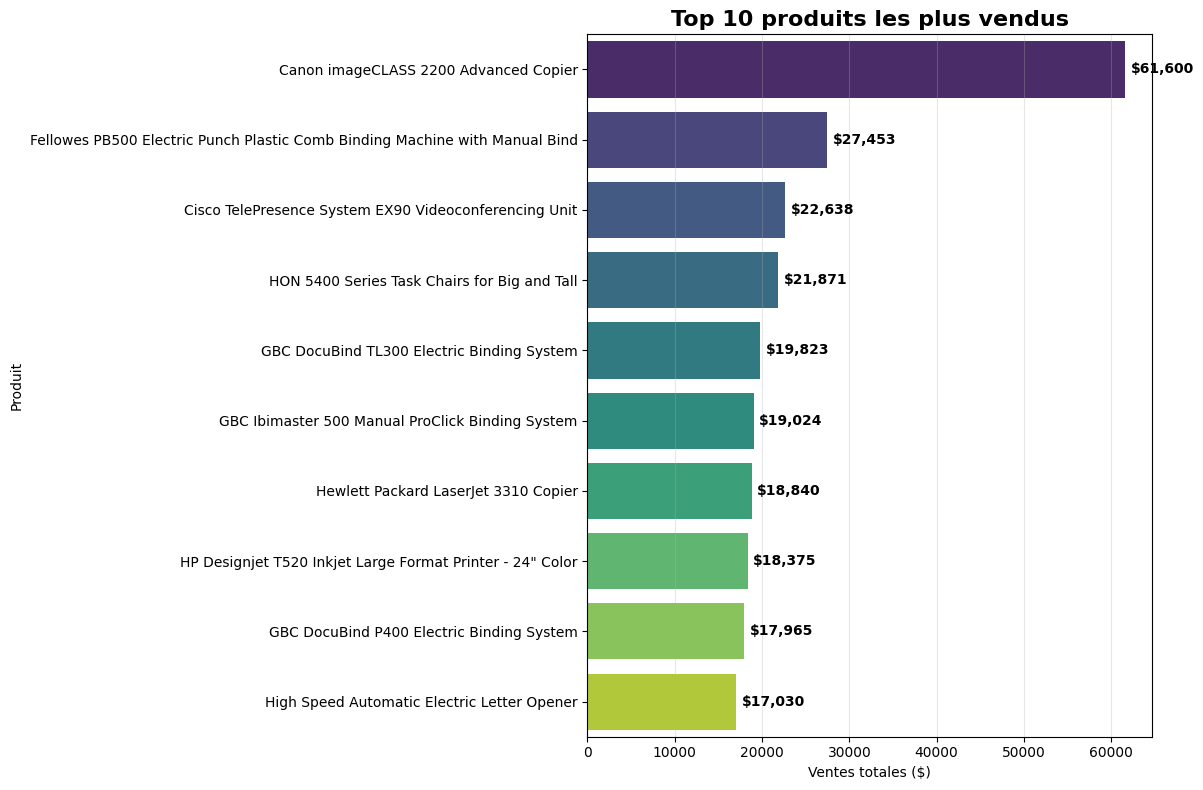

In [4]:
#Top 10 produits les plus vendus (Seaborn)

# On regroupe par produit, on trie et on garde les 10 premiers
top_products = (df.groupby('Product Name')['Sales']
                  .sum()
                  .sort_values(ascending=False)
                  .head(10))

plt.figure(figsize=(12, 8))
ax = sns.barplot(x=top_products.values, y=top_products.index,
                 palette='viridis', orient='h')

# On ajoute la valeur exacte au bout de chaque barre
for i, val in enumerate(top_products.values):
    ax.text(val + max(top_products.values) * 0.01, i,
            f'${val:,.0f}', va='center', fontsize=10, fontweight='bold')

plt.title('Top 10 produits les plus vendus', fontsize=16, fontweight='bold')
plt.xlabel('Ventes totales ($)')
plt.ylabel('Produit')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

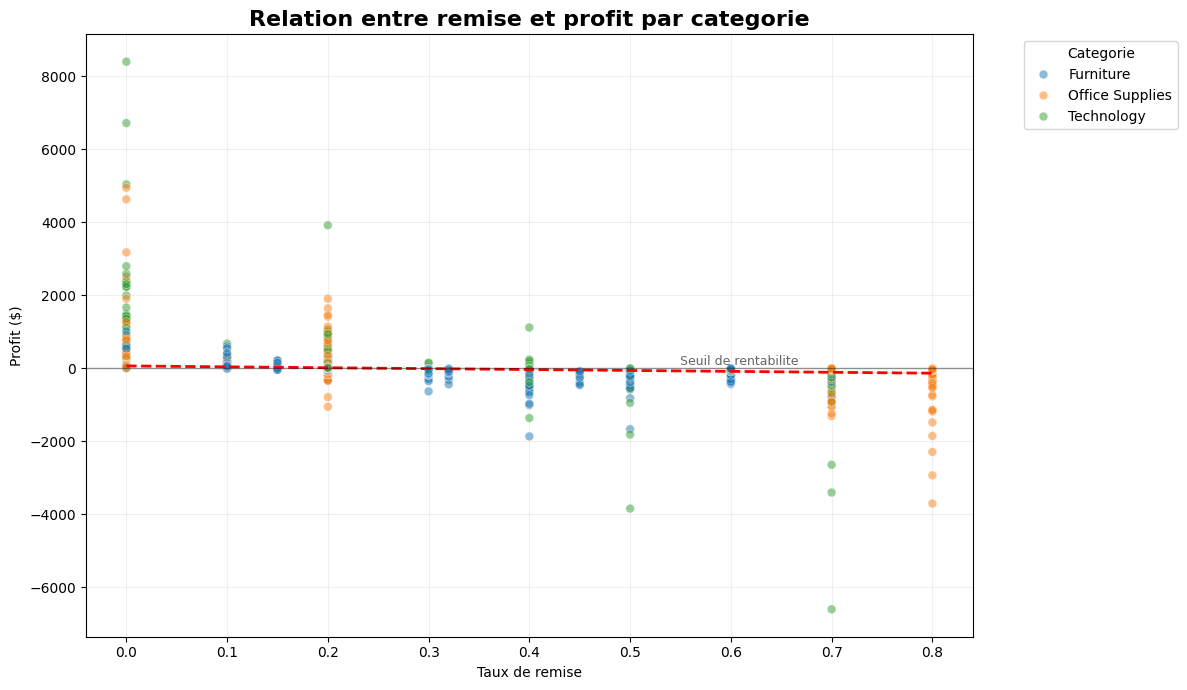

Transactions avec remise > 20%     : 1,393
Profit moyen sur ces transactions  : $-97.18
Pourcentage de ces ventes en perte : 96.8%


In [5]:
#Nuage de points Profit vs Remise (Seaborn)


plt.figure(figsize=(12, 7))

# Chaque point = une transaction
# hue colorie les points selon la categorie
# alpha rend les points transparents pour voir les superpositions
sns.scatterplot(data=df, x='Discount', y='Profit',
                hue='Category', alpha=0.5, s=40)

# Droite de tendance generale en rouge
sns.regplot(data=df, x='Discount', y='Profit',
            scatter=False, color='red',
            line_kws={'linewidth': 2, 'linestyle': '--', 'label': 'Tendance'})

# Ligne horizontale a zero : en dessous = perte
plt.axhline(y=0, color='black', linewidth=1, alpha=0.4)
plt.text(0.55, 100, 'Seuil de rentabilite', fontsize=9, alpha=0.6)

plt.title('Relation entre remise et profit par categorie',
          fontsize=16, fontweight='bold')
plt.xlabel('Taux de remise')
plt.ylabel('Profit ($)')
plt.legend(title='Categorie', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

# Quelques chiffres cles pour appuyer l'analyse
high_disc = df[df['Discount'] > 0.2]
print(f"Transactions avec remise > 20%     : {len(high_disc):,}")
print(f"Profit moyen sur ces transactions  : ${high_disc['Profit'].mean():.2f}")
print(f"Pourcentage de ces ventes en perte : {(high_disc['Profit'] < 0).mean()*100:.1f}%")

In [6]:
#Analyse comparative Matplotlib vs Seaborn

print("ANALYSE COMPARATIVE : MATPLOTLIB vs SEABORN\n")

print("MATPLOTLIB")
print("- Necessite plus de code pour obtenir un resultat esthetique")
print("- Offre un controle precis sur chaque element du graphique")
print("- Indispensable pour les graphiques interactifs avec ipywidgets")
print("- Ideal quand on veut personnaliser chaque detail\n")

print("SEABORN")
print("- Moins de code pour un resultat professionnel")
print("- Fonctions statistiques integrees comme regplot")
print("- Palettes de couleurs automatiques et harmonieuses")
print("- Ideal pour communiquer des resultats a un public non technique\n")

print("PLOTLY")
print("- Le seul qui permet de faire des cartes geografiques facilement")
print("- Interactivite native : zoom, survol, clic sans ipywidgets")
print("- Ideal pour les dashboards et les rapports partages en ligne\n")

print("CONCLUSION")
print("- Exploration rapide       -> Seaborn")
print("- Controle et interactivite -> Matplotlib + ipywidgets")
print("- Cartes et dashboards     -> Plotly")


ANALYSE COMPARATIVE : MATPLOTLIB vs SEABORN

MATPLOTLIB
- Necessite plus de code pour obtenir un resultat esthetique
- Offre un controle precis sur chaque element du graphique
- Indispensable pour les graphiques interactifs avec ipywidgets
- Ideal quand on veut personnaliser chaque detail

SEABORN
- Moins de code pour un resultat professionnel
- Fonctions statistiques integrees comme regplot
- Palettes de couleurs automatiques et harmonieuses
- Ideal pour communiquer des resultats a un public non technique

PLOTLY
- Le seul qui permet de faire des cartes geografiques facilement
- Interactivite native : zoom, survol, clic sans ipywidgets
- Ideal pour les dashboards et les rapports partages en ligne

CONCLUSION
- Exploration rapide       -> Seaborn
- Controle et interactivite -> Matplotlib + ipywidgets
- Cartes et dashboards     -> Plotly
